In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Problem 1: the Old Faithful

The data contains waiting times between eruptions and the duration of the eruptions for the Old Faithful geyser in Yellowstone National Park, Wyoming, USA

In [2]:
url = 'https://raw.githubusercontent.com/um-perez-alvaro/Data-Science-Practice/master/Data/faithful.csv'
data = pd.read_csv(url,sep = '\s+')
data.head()

,eruptions,waiting
1,3.600,79
2,1.800,54
3,3.333,74
4,2.283,62
5,4.533,85


![old faithful](old_faithful.jpg)

Text(0.5, 0, 'duration of eruption')

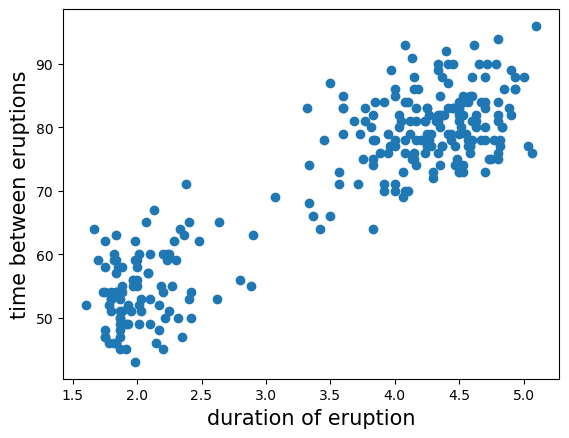

In [3]:
plt.scatter(data.eruptions, data.waiting)
plt.ylabel('time between eruptions', fontsize=15)
plt.xlabel('duration of eruption', fontsize=15)

**Part 1:** Fit a Gaussian Mixture model to the data (with 2 components)

In [5]:


from sklearn.mixture import GaussianMixture
gm = GaussianMixture(n_components=2)
gm.fit(data)



GaussianMixture(n_components=2)

**Part 2:** plot decision boundaries and density contours.

In [6]:
def plot_gaussian_mixture(model, X):
    from matplotlib.colors import LogNorm    
    # feature names
    try:
        feature_names = X.columns
    except:
        feature_names = ['feature #1','feature #2']
    
    # put data into numpy arrays
    try:
        X = np.array(X)
    except:
        print('something went wrong')
    
    
    resolution = 1000
    
    # create a mesh grid
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    Z = -model.score_samples(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z,
                 norm=LogNorm(vmin=1.0, vmax=30.0),
                 levels=np.logspace(0, 2, 12))
    plt.contour(xx, yy, Z,
                norm=LogNorm(vmin=1.0, vmax=30.0),
                levels=np.logspace(0, 2, 12),
                linewidths=1, colors='k')

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contour(xx, yy, Z,
                linewidths=2, colors='r', linestyles='dashed')
    
    # plot data
    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)
    
    # plot centroids
    centroids = model.means_
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='o', s=20, linewidths=8,
                color='w', zorder=10, alpha=0.9)
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='x', s=50, linewidths=2,
                color='r', zorder=11, alpha=1)

    plt.xlabel(feature_names[0], fontsize=15)
    plt.ylabel(feature_names[1], fontsize=15)

/Users/vanmagnan/opt/anaconda3/lib/python3.8/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but GaussianMixture was fitted with feature names
  warnings.warn(
/Users/vanmagnan/opt/anaconda3/lib/python3.8/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but GaussianMixture was fitted with feature names
  warnings.warn(


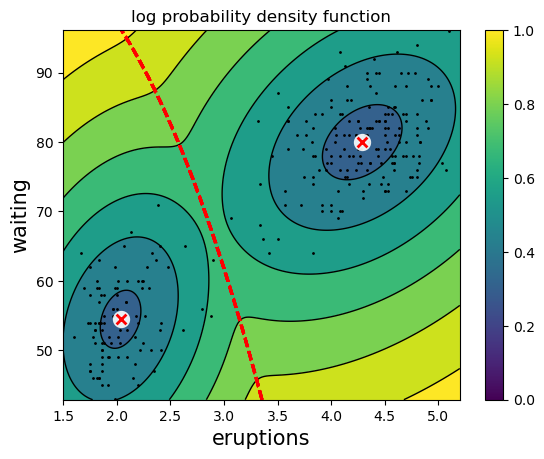

In [7]:


plt.title('log probability density function')
plot_gaussian_mixture(gm, data)
plt.colorbar()

